# IDRiD — EfficientNet Embeddings + **SVM** (Binary: No DR=0, DR≥1=1)

This notebook uses ImageNet-pretrained EfficientNet-B0 to extract embeddings and trains an **SVM** for the binary task (No DR=0, DR≥1=1).

**Pipeline**
1) Circular crop + optional CLAHE → extract 1280-D features with EfficientNet-B0 (frozen)  
2) Standardize (+ optional PCA) → **SVM** (linear/RBF) with class balancing  
3) Grid search on validation; **threshold tuning**  
4) Refit on Train+Val → **Test** (confusion matrix, ROC, PR)

**Paths**
- CSV: `/kaggle/input/idrid-dataset/idrid_labels.csv`  
- Images: `/kaggle/input/idrid-dataset/Imagenes/Imagenes/{id_code}.jpg`


In [2]:
import os, random, warnings, copy, math, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             roc_curve, roc_auc_score, precision_recall_curve, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
seed_everything()

# Preprocessing toggles
ENABLE_CIRCULAR_CROP = True
ENABLE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = 8

# SVM search space
PCA_DIM_GRID = [0, 128]   # 0 = no PCA
KERNEL_GRID  = ["linear", "rbf"]
C_GRID       = [0.1, 1, 3, 10]
GAMMA_GRID   = ["scale", 0.01, 0.001]  # only for RBF

BATCH_SIZE_FEATS = 64  # for feature extraction


Device: cpu


In [3]:
CSV_PATH = "/kaggle/input/idrid-dataset/idrid_labels.csv"
IMG_DIR  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"

# Robust read
try:
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]
except Exception:
    df = pd.read_csv(CSV_PATH, usecols=[0,1])
    df.columns = ["id_code", "diagnosis"]

df = df[[c for c in df.columns if c.lower() in ("id_code","diagnosis")]].copy()
df.columns = ["id_code","diagnosis"]
df["diagnosis"] = df["diagnosis"].astype(int)
df["label"] = (df["diagnosis"]>0).astype(int)

def build_img_path(id_code):
    base = Path(IMG_DIR) / f"{id_code}"
    for ext in [".jpg",".JPG",".png",".jpeg",".JPEG"]:
        p = base.with_suffix(ext)
        if p.exists(): return str(p)
    return str(base.with_suffix(".jpg"))

df["image_path"] = df["id_code"].apply(build_img_path)
print(df.head())
print("\nBinary distribution:\n", df["label"].value_counts().sort_index())


     id_code  diagnosis  label  \
0  IDRiD_001          3      1   
1  IDRiD_002          3      1   
2  IDRiD_003          2      1   
3  IDRiD_004          3      1   
4  IDRiD_005          4      1   

                                          image_path  
0  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
1  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
2  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
3  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
4  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  

Binary distribution:
 label
0    129
1    326
Name: count, dtype: int64


In [4]:
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df, df["label"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(temp_df, temp_df["label"]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{name}: {len(d)} |", d["label"].value_counts().sort_index().to_dict())


train: 318 | {0: 90, 1: 228}
val: 68 | {0: 19, 1: 49}
test: 69 | {0: 20, 1: 49}


In [5]:
import numpy as np

def center_square_crop(np_img):
    h,w = np_img.shape[:2]; s = min(h,w)
    y0 = (h-s)//2; x0 = (w-s)//2
    return np_img[y0:y0+s, x0:x0+s]

def circular_crop(np_img, margin=0.02):
    sq = center_square_crop(np_img)
    h,w = sq.shape[:2]
    r = int(0.5*min(h,w)*(1.0-margin)); cy,cx = h//2,w//2
    Y,X = np.ogrid[:h,:w]
    mask = (X-cx)**2 + (Y-cy)**2 <= r*r
    out = np.zeros_like(sq); out[mask] = sq[mask]
    return out

def apply_clahe_green(np_img, clip=2.0, grid=8):
    try:
        import cv2
        bgr = cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR)
        g = bgr[:,:,1]
        clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(grid),int(grid)))
        g_eq = clahe.apply(g)
        bgr[:,:,1] = g_eq
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    except Exception:
        g = np_img[:,:,1].astype(np.float32)
        g = (g - g.min())/max(1e-6, g.max()-g.min())
        np_img2 = np_img.copy()
        np_img2[:,:,1] = (g*255.0).astype(np.uint8)
        return np_img2

class Preprocessor:
    def __init__(self, circ=True, clahe=True, clip=2.0, grid=8):
        self.circ, self.clahe, self.clip, self.grid = circ, clahe, clip, grid
    def __call__(self, pil_img):
        np_img = np.array(pil_img)
        if self.circ:  np_img = circular_crop(np_img, margin=0.02)
        if self.clahe: np_img = apply_clahe_green(np_img, clip=self.clip, grid=self.grid)
        return Image.fromarray(np_img)

preproc = Preprocessor(ENABLE_CIRCULAR_CROP, ENABLE_CLAHE, CLAHE_CLIP, CLAHE_GRID)


In [6]:
eval_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class IDRiDFeatDS(Dataset):
    def __init__(self, df, transform, preproc=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform; self.preproc = preproc
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.preproc is not None: img = self.preproc(img)
        img = self.transform(img)
        label = int(row["label"])
        return img, label, row["id_code"]

train_feat_ds = IDRiDFeatDS(train_df, eval_tfms, preproc=preproc)
val_feat_ds   = IDRiDFeatDS(val_df,   eval_tfms, preproc=preproc)
test_feat_ds  = IDRiDFeatDS(test_df,  eval_tfms, preproc=preproc)

BATCH_SIZE_FEATS = 64
train_feat_loader = DataLoader(train_feat_ds, batch_size=BATCH_SIZE_FEATS, shuffle=False, num_workers=2, pin_memory=True)
val_feat_loader   = DataLoader(val_feat_ds,   batch_size=BATCH_SIZE_FEATS, shuffle=False, num_workers=2, pin_memory=True)
test_feat_loader  = DataLoader(test_feat_ds,  batch_size=BATCH_SIZE_FEATS, shuffle=False, num_workers=2, pin_memory=True)


In [7]:
try:
    from torchvision.models import EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    backbone = models.efficientnet_b0(weights=weights)
except Exception:
    backbone = models.efficientnet_b0(pretrained=True)

embedder = copy.deepcopy(backbone)
embedder.classifier = nn.Identity()
embedder = embedder.to(device)
embedder.eval()

@torch.no_grad()
def extract_embeddings(loader):
    feats, labels, ids = [], [], []
    for x, y, idc in loader:
        x = x.to(device)
        f = embedder(x)          # [B, 1280]
        feats.append(f.cpu().numpy())
        labels.append(y.numpy())
        ids.extend(list(idc))
    return np.concatenate(feats), np.concatenate(labels), ids

print("Extracting embeddings...")
X_tr, y_tr, ids_tr = extract_embeddings(train_feat_loader)
X_va, y_va, ids_va = extract_embeddings(val_feat_loader)
X_te, y_te, ids_te = extract_embeddings(test_feat_loader)
print("Shapes:", X_tr.shape, X_va.shape, X_te.shape)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s] 


Extracting embeddings...
Shapes: (318, 1280) (68, 1280) (69, 1280)


,pca_dim,kernel,C,gamma,val_f1,val_acc
0,128,rbf,3.0,0.001,0.979167,0.970588
1,128,rbf,10.0,0.001,0.969072,0.955882
2,128,rbf,3.0,scale,0.969072,0.955882
3,0,rbf,10.0,0.001,0.959184,0.941176
4,128,rbf,10.0,scale,0.959184,0.941176
5,0,rbf,3.0,scale,0.959184,0.941176
6,0,rbf,3.0,0.001,0.959184,0.941176
7,0,rbf,10.0,scale,0.959184,0.941176
8,128,rbf,1.0,0.001,0.957447,0.941176
9,128,rbf,1.0,scale,0.957447,0.941176


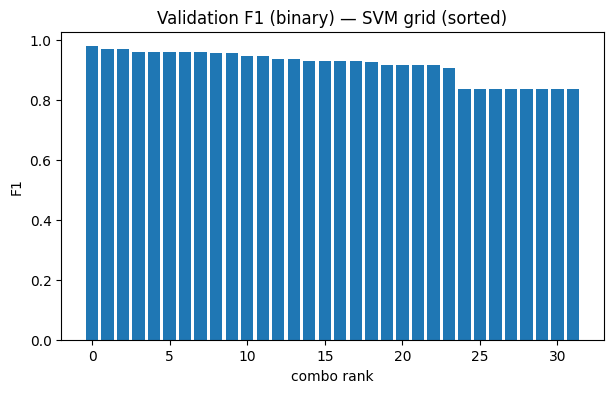

Best HP: {'pca_dim': 128, 'kernel': 'rbf', 'C': 3, 'gamma': 0.001} Best Val F1: 0.9791666666666666


In [8]:
def fit_svm_with_preproc(X_train, y_train, X_val, y_val, pca_dim, kernel, C, gamma="scale"):
    # Standardize
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xv  = scaler.transform(X_val)
    pca = None
    if pca_dim and pca_dim > 0:
        pca = PCA(n_components=min(pca_dim, Xtr.shape[1]))
        Xtr = pca.fit_transform(Xtr)
        Xv  = pca.transform(Xv)

    if kernel == "linear":
        clf = SVC(kernel="linear", C=C, class_weight="balanced", probability=True, random_state=SEED)
    else:
        clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", probability=True, random_state=SEED)
    clf.fit(Xtr, y_train)

    prob = clf.predict_proba(Xv)[:,1]
    preds = (prob >= 0.5).astype(int)
    f1 = f1_score(y_val, preds, average="binary")
    acc = accuracy_score(y_val, preds)
    return f1, acc, scaler, pca, clf

# Grid
PCA_DIM_GRID = [0, 128]
KERNEL_GRID  = ["linear", "rbf"]
C_GRID       = [0.1, 1, 3, 10]
GAMMA_GRID   = ["scale", 0.01, 0.001]

results = []
best = {"f1": -1, "state": None, "hp": None}

for pca_dim in PCA_DIM_GRID:
    for kernel in KERNEL_GRID:
        for C in C_GRID:
            gammas = GAMMA_GRID if kernel=="rbf" else ["scale"]
            for gamma in gammas:
                f1, acc, scaler, pca, clf = fit_svm_with_preproc(X_tr, y_tr, X_va, y_va, pca_dim, kernel, C, gamma)
                results.append({"pca_dim":pca_dim,"kernel":kernel,"C":C,"gamma":gamma,"val_f1":f1,"val_acc":acc})
                if f1 > best["f1"]:
                    best["f1"] = f1
                    best["hp"] = {"pca_dim":pca_dim,"kernel":kernel,"C":C,"gamma":gamma}
                    best["state"] = {"scaler":scaler, "pca":pca, "clf":clf}

res_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
display(res_df.head(20))

plt.figure(figsize=(7,4))
plt.bar(range(len(res_df)), res_df["val_f1"].values)
plt.title("Validation F1 (binary) — SVM grid (sorted)")
plt.xlabel("combo rank"); plt.ylabel("F1")
plt.show()

print("Best HP:", best["hp"], "Best Val F1:", best["f1"])


Best threshold (F1 on val): 0.5


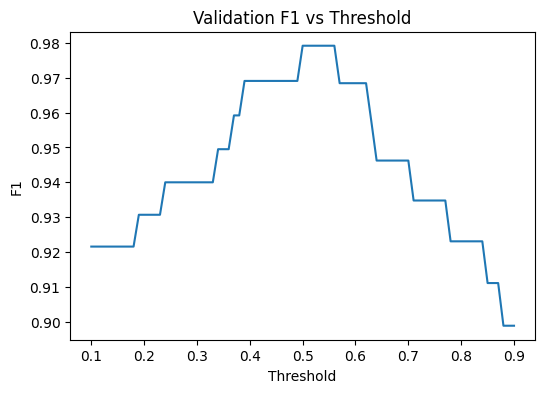

In [9]:
scaler = best["state"]["scaler"]; pca = best["state"]["pca"]; clf = best["state"]["clf"]
Xv = scaler.transform(X_va)
if pca is not None:
    Xv = pca.transform(Xv)
val_probs = clf.predict_proba(Xv)[:,1]

ths = np.linspace(0.1, 0.9, 81)
f1s = [f1_score(y_va, (val_probs>=t).astype(int)) for t in ths]
best_t = float(ths[int(np.argmax(f1s))])
print("Best threshold (F1 on val):", best_t)

plt.figure(figsize=(6,4))
plt.plot(ths, f1s)
plt.title("Validation F1 vs Threshold")
plt.xlabel("Threshold"); plt.ylabel("F1")
plt.show()



== Test metrics (default 0.5 threshold) ==
Default 0.5 — Acc=0.9130 | F1=0.9375 | Prec=0.9574 | Rec=0.9184

== Test metrics (tuned threshold) ==
Tuned 0.500 — Acc=0.9130 | F1=0.9375 | Prec=0.9574 | Rec=0.9184


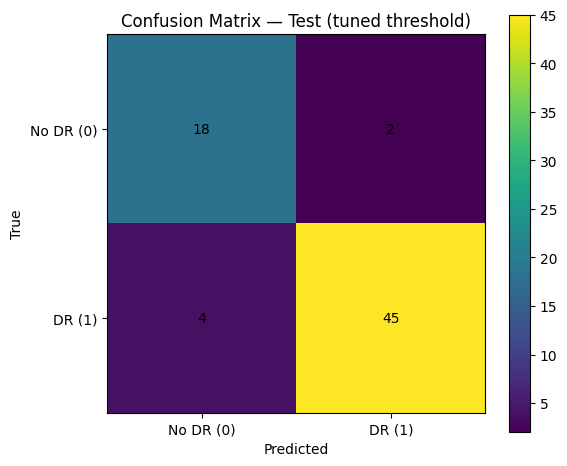

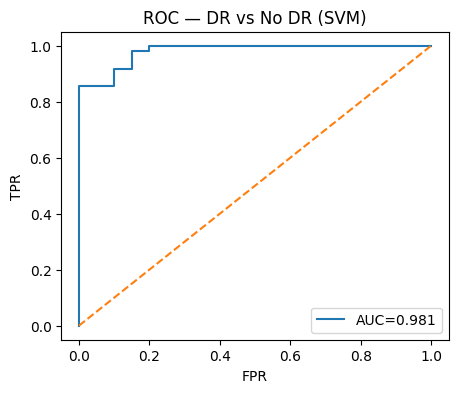

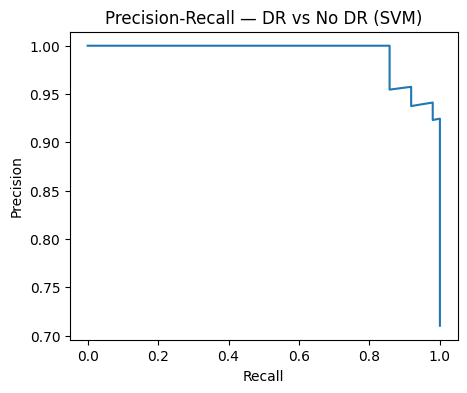

In [10]:
# Merge train + val
X_tv = np.concatenate([X_tr, X_va], axis=0)
y_tv = np.concatenate([y_tr, y_va], axis=0)

hp = best["hp"]
# Refit preprocessing
scaler = StandardScaler()
X_tv_s = scaler.fit_transform(X_tv)
X_te_s = scaler.transform(X_te)

pca = None
if hp["pca_dim"] and hp["pca_dim"]>0:
    pca = PCA(n_components=min(hp["pca_dim"], X_tv_s.shape[1]))
    X_tv_s = pca.fit_transform(X_tv_s)
    X_te_s = pca.transform(X_te_s)

# Refit SVM
if hp["kernel"] == "linear":
    clf = SVC(kernel="linear", C=hp["C"], class_weight="balanced", probability=True, random_state=SEED)
else:
    clf = SVC(kernel="rbf", C=hp["C"], gamma=hp["gamma"], class_weight="balanced", probability=True, random_state=SEED)
clf.fit(X_tv_s, y_tv)

# Test predictions
test_probs = clf.predict_proba(X_te_s)[:,1]
test_preds_default = (test_probs>=0.5).astype(int)
test_preds_tuned   = (test_probs>=best_t).astype(int)

def eval_and_print(y_true, preds, probs, title):
    acc = accuracy_score(y_true, preds)
    f1b = f1_score(y_true, preds, average="binary")
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    print(f"{title} — Acc={acc:.4f} | F1={f1b:.4f} | Prec={prec:.4f} | Rec={rec:.4f}")

print("\n== Test metrics (default 0.5 threshold) ==")
eval_and_print(y_te, test_preds_default, test_probs, "Default 0.5")

print("\n== Test metrics (tuned threshold) ==")
eval_and_print(y_te, test_preds_tuned, test_probs, f"Tuned {best_t:.3f}")

# Confusion Matrix (tuned)
cm = confusion_matrix(y_te, test_preds_tuned, labels=[0,1])
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — Test (tuned threshold)")
plt.colorbar()
plt.xticks([0,1], ["No DR (0)","DR (1)"])
plt.yticks([0,1], ["No DR (0)","DR (1)"])
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

# ROC & PR (probabilities)
fpr, tpr, _ = roc_curve(y_te, test_probs)
auc = roc_auc_score(y_te, test_probs)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC — DR vs No DR (SVM)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend()
plt.show()

prec, rec, _ = precision_recall_curve(y_te, test_probs)
plt.figure(figsize=(5,4))
plt.plot(rec, prec)
plt.title("Precision-Recall — DR vs No DR (SVM)")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()


In [11]:
OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)

artifact = {
    "scaler": scaler,
    "pca": pca,
    "svm": clf,
    "hp": hp,
    "best_threshold": best_t
}
joblib.dump(artifact, OUT/"svm_embedding_pipeline.pkl")

pd.DataFrame({
    "id_code": ids_te,
    "true": y_te,
    "prob": test_probs,
    "pred_default": test_preds_default,
    "pred_tuned": test_preds_tuned
}).to_csv(OUT/"test_predictions_svm.csv", index=False)

# (Optional) Save features; comment out if space is tight
np.save(OUT/"features_train.npy", X_tr)
np.save(OUT/"features_val.npy",   X_va)
np.save(OUT/"features_test.npy",  X_te)

print("Saved:")
print(" -", OUT/"svm_embedding_pipeline.pkl")
print(" -", OUT/"test_predictions_svm.csv")
print(" -", OUT/"features_{train,val,test}.npy")


Saved:
 - outputs/svm_embedding_pipeline.pkl
 - outputs/test_predictions_svm.csv
 - outputs/features_{train,val,test}.npy
